<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
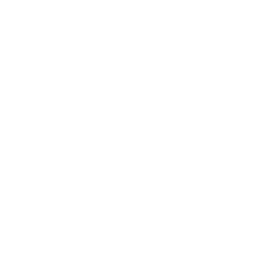
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC FACTEX — split-plot uspořádání pro zemědělský polní pokus</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Zohlednění polních omezení vnořením odrůdových ošetření do bloků zavlažování &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Manažerské shrnutí

Agronom porovnává dva režimy zavlažování (kapkové vs. záplavové) napříč dvěma
odrůdami plodin a dvěma dávkami hnojiva v polním pokusu. Zavlažovací zařízení
nelze během dne přesouvat mezi sousedními parcelami, takže zavlažování je
faktorem **hlavní parcely** (obtížně měnitelný), zatímco odrůda a hnojení jsou
faktory **dílčí parcely**, které lze volně randomizovat uvnitř každého
zavlažovaného pásu. Toto *omezení randomizace* definuje experiment typu
**split-plot**.

`PROC FACTEX` sestaví návrh ošetření 2&times;2&times;2 a rozdělí jej do bloků tak, aby
faktor hlavní parcely zůstal v rámci každého bloku konstantní — to je
charakteristický rys uspořádání split-plot na úrovni návrhu. Návrh je poté
replikován ve třech polních opakováních (24 parcel) a analyzován pomocí
`PROC MIXED`, modelu, který správně odděluje chybu hlavní parcely od chyby
dílčí parcely.

Napasovaný model přímo obnovuje strukturu rozptylu split-plot: **rozptyl
hlavní parcely (0,27)** je zhruba šestkrát vyšší než **reziduální rozptyl
dílčí parcely (0,046)**, což potvrzuje, že parcely sdílející stejný
zavlažovací pás jsou pozitivně korelované. Proto test zavlažování na úrovni
hlavní parcely má pouze **4,3 jmenovatelových stupňů volnosti** (F = 4,10,
p = 0,108), zatímco test odrůdy na úrovni dílčí parcely má **16** (F = 16,33,
p = 0,0009). Odrůda je jasně významný efekt; zavlažování je odhadnuto s mnohem
nižší přesností — přesně ten kompromis, který split-plot přináší, a důvod,
proč běžná dvoufaktorová ANOVA (která by obě chyby sloučila) by nadhodnotila
průkaznost zavlažování.


## Zdroje dat

Žádná externí vstupní data. `PROC FACTEX` generuje návrh ošetření; krátký krok
DATA jej replikuje napříč polními opakováními a simuluje výnosy parcel, aby
analýza split-plot měla odezvu k modelování. Každé číslo uvedené v tomto
sešitu je vytvořeno buňkami kódu níže.


---


In [1]:
/* Vygenerovat návrh ošetření 2x2x2 a rozdělit jej do bloků tak,     */
/* aby faktor hlavní parcely (zavlažování) byl v rámci bloku stálý.  */
/* BLOCKS=2 rozdělí osm běhů do dvou hlavních parcel, jedné pro       */
/* každý režim zavlažování; odrůda a hnojení se mění uvnitř parcely.  */
PROCEDURA factex;
  factors Irrig Variety Fertil;
  blocks = 2;
  examine design;
  VÝSTUP out = sp_design
    Irrig   = (-1 1)
    Variety = (-1 1)
    Fertil  = (-1 1);
SPUSTIT;

/* Zobrazit kódovaný návrh s přiřazením bloku (hlavní parcely) */
PROCEDURA TISK data = sp_design noobs ŠTÍTEK;
  PROMĚNNÁ BLOCK Irrig Variety Fertil;
  ŠTÍTEK BLOCK   = 'Hlavní parcela (blok)'
        Irrig   = 'Zavlažování'
        Variety = 'Odrůda'
        Fertil  = 'Hnojení';
  NÁZEV 'Návrh ošetření split-plot z PROC FACTEX';
SPUSTIT;



                    The FACTEX Procedure
                    Design Examination

  Number of runs:      8
  Number of factors:   3
  Number of blocks:    2
  D-efficiency:        100.0%
  Orthogonal:          Yes



                    The FACTEX Procedure

  Factors:    3
  Runs:       8
  Blocks:     2

  Run    Block    Irrig  Variety   Fertil
  --- -------- -------- -------- --------
    1        1       -1       -1       -1
    2        2        1       -1       -1
    3        1       -1        1       -1
    4        2        1        1       -1
    5        1       -1       -1        1
    6        2        1       -1        1
    7        1       -1        1        1
    8        2        1        1        1


                                        Návrh ošetření split-plot z PROC FACTEX                                         

 Hlavní parcela (blok)     Zavlažování   Odrůda   Hnojení
                     1              -1       -1        -1
                     2          


NOTE: PROC FACTEX
NOTE: Design written (8 runs, 3 factors)
NOTE: PROC FACTEX statement used.
NOTE: PROC PRINT data=sp_design

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---


**Čtení návrhu.** Tabulka EXAMINE uvádí **8 běhů, 2 bloky**, 100%
D-efektivitu a ortogonální uspořádání. Ve vytištěném návrhu každý řádek s
`Irrig = -1` spadá do bloku 1 a každý řádek s `Irrig = +1` spadá do bloku 2:
**blok *je* úroveň zavlažování**. To je omezení randomizace typu split-plot
vyjádřené již na úrovni návrhu — zavlažování se mění pouze na hranici bloku
(hlavní parcely), zatímco odrůda a hnojení nabývají všech čtyř kombinací
*uvnitř* každého bloku.


---


In [2]:
/* Replikovat osmiběhový návrh přes tři polní opakování a simulovat  */
/* výnos parcely. Každá dvojice (zavlažování, opakování) je jedna     */
/* hlavní parcela.                                                     */
data trial;
  NASTAVIT sp_design;
  DÉLKA Irrigation $5 Variety_c $2;
  KDYŽ Irrig   = -1 PAK Irrigation = 'Drip'; JINAK Irrigation = 'Flood';
  KDYŽ Variety = -1 PAK Variety_c  = 'V1';   JINAK Variety_c  = 'V2';
  Fert_kg = 60 + 40*(Fertil = 1);          /* 60 nebo 100 kg N/ha */

  CALL streaminit(2024);
  OPAKUJ Rep = 1 TO 3;
    /* Identifikátor hlavní parcely: zavlažovací pás v rámci opakování */
    WholePlot = catx('-', Irrigation, ZAPSAT(Rep, 1.));
    yield_tha = 5.8
              + 0.90*(Irrig   =  1)          /* nárůst při záplavě     */
              + 0.50*(Variety =  1)          /* nárůst odrůdy V2       */
              + 0.35*(Fertil  =  1)          /* nárůst vyššího N       */
              + 0.15*(Irrig=1)*(Variety=1)   /* mírná interakce        */
              + rand('normal', 0, 0.25);     /* šum dílčí parcely      */
    VÝSTUP;
  KONEC;
SPUSTIT;

PROCEDURA TISK data = trial(obs = 8) noobs ŠTÍTEK;
  PROMĚNNÁ Rep WholePlot Irrigation Variety_c Fert_kg yield_tha;
  ŠTÍTEK Rep        = 'Opakování'
        WholePlot  = 'Hlavní parcela'
        Irrigation = 'Zavlažování'
        Variety_c  = 'Odrůda'
        Fert_kg    = 'N (kg/ha)'
        yield_tha  = 'Výnos (t/ha)';
  FORMÁT yield_tha 6.2;
  NÁZEV 'Uspořádání polního pokusu (prvních 8 z 24 parcel)';
SPUSTIT;


                                   Uspořádání polního pokusu (prvních 8 z 24 parcel)                                    

  Opakování   Hlavní parcela     Zavlažování   Odrůda  N (kg/ha)   Výnos (t/ha)
          1  Drip-1           Drip            V1              60           6.03
          2  Drip-2           Drip            V1              60           5.87
          3  Drip-3           Drip            V1              60           5.03
          1  Flood-1          Flood           V1              60           6.90
          2  Flood-2          Flood           V1              60           6.26
          3  Flood-3          Flood           V1              60           6.61
          1  Drip-1           Drip            V2              60           6.14
          2  Drip-2           Drip            V2              60           6.12

... 16 more observations (showing 8 of 24)




NOTE: DATA trial


NOTE: Read 8 rows from sp_design.
NOTE: Wrote trial (24 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


---


In [3]:
/* Průměry buněk ošetření napříč 24 parcelami */
PROCEDURA PRŮMĚRY data = trial n mean std maxdec=2;
  TŘÍDA Irrigation Variety_c;
  PROMĚNNÁ yield_tha;
  ŠTÍTEK Irrigation = 'Zavlažování' Variety_c = 'Odrůda' yield_tha = 'Výnos (t/ha)';
  NÁZEV 'Průměrný výnos podle zavlažování a odrůdy';
SPUSTIT;


                                       Průměrný výnos podle zavlažování a odrůdy                                        

                                                  The MEANS Procedure

                                      Analysis Variable : yield_tha Výnos (t/ha)

        Zavlažování     Odrůda            N Obs           Mean        Std Dev
        ---------------------------------------------------------------------
        Drip            V1                    6           5.93           0.46
        Drip            V2                    6           6.42           0.24
        Flood           V1                    6           6.84           0.40
        Flood           V2                    6           7.58           0.19
        ---------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                       Průměrný výnos podle zavlažování a odrůdy                                        




NOTE: PROC SGPLOT data=trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


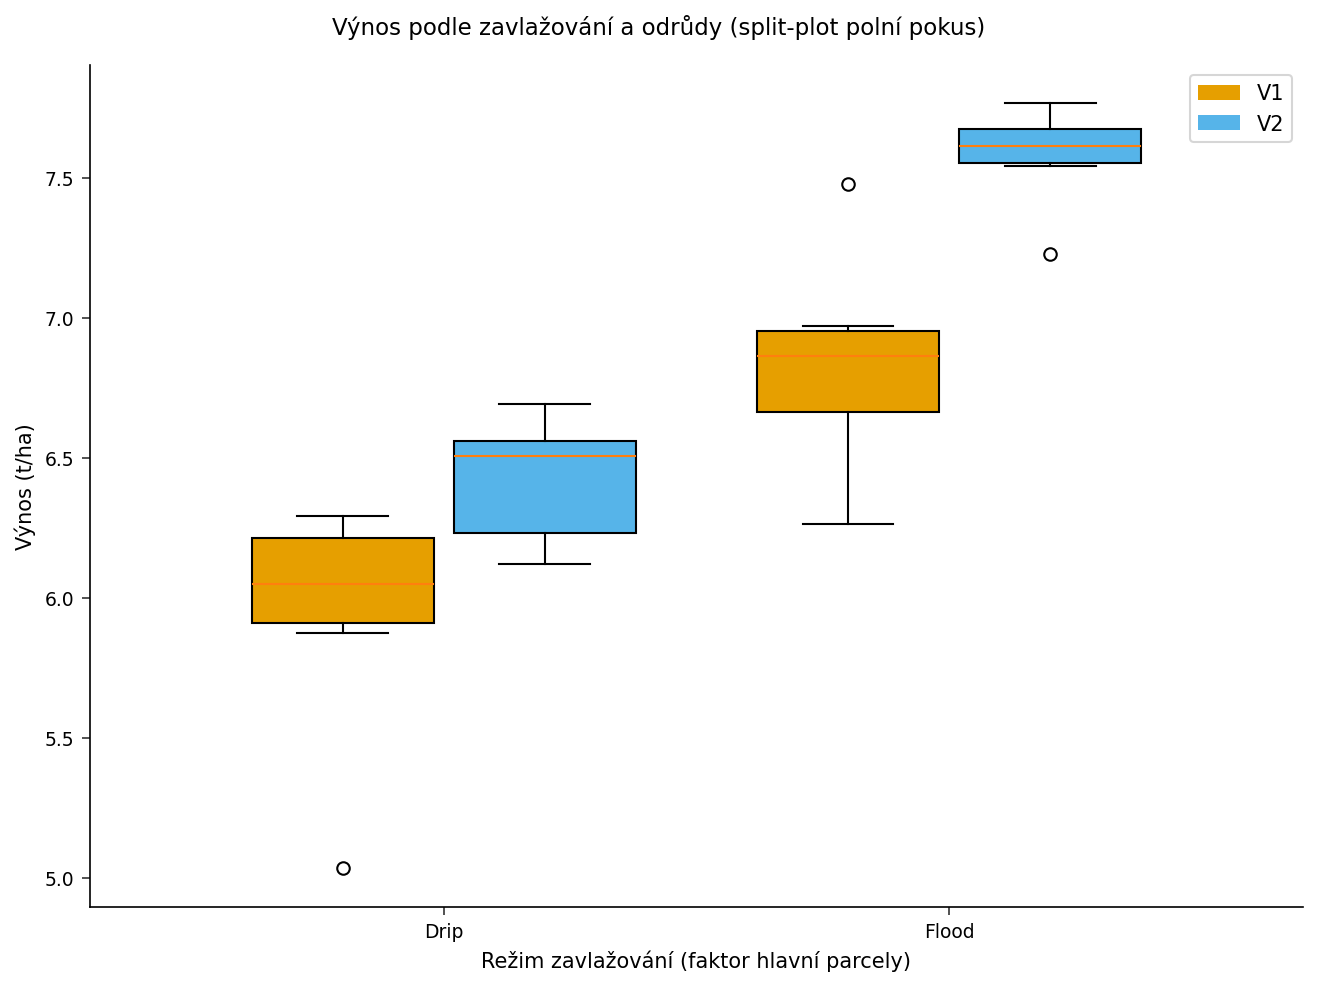

In [4]:
/* Vizualizace rozdělení výnosu podle režimu zavlažování a odrůdy */
PROCEDURA SGPLOT data = trial;
  VBOX yield_tha / category=Irrigation GROUP=Variety_c;
  XAXIS ŠTÍTEK = 'Režim zavlažování (faktor hlavní parcely)';
  YAXIS ŠTÍTEK = 'Výnos (t/ha)';
  keylegend / NÁZEV='Odrůda';
  NÁZEV 'Výnos podle zavlažování a odrůdy (split-plot polní pokus)';
SPUSTIT;


---


In [5]:
/* Analýza split-plot: PROC MIXED odděluje chybu hlavní parcely      */
/* (variabilitu mezi zavlažovacími pásy) od chyby dílčí parcely.      */
/* RANDOM WholePlot poskytuje vrstvu chyby hlavní parcely.            */
PROCEDURA MIXED data = trial PLOTS = none;
  TŘÍDA Irrigation Variety_c WholePlot;
  MODEL yield_tha = Irrigation Variety_c Irrigation*Variety_c
        / ddfm = satterthwaite;
  RANDOM WholePlot;
  ŠTÍTEK yield_tha = 'Výnos (t/ha)' Irrigation = 'Zavlažování'
        Variety_c = 'Odrůda' WholePlot = 'Hlavní parcela';
  NÁZEV 'Split-plot smíšený model — zavlažování (hlavní parcela) x odrůda (dílčí parcela)';
SPUSTIT;


                                       Průměrný výnos podle zavlažování a odrůdy                                        

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable          Výnos (t/ha)
Estimation Method                   REML
Degrees of Freedom Method  Satterthwaite
Number of Observations                24

Covariance Parameter Estimates

Cov Parm   Estimate
---------  --------
Wholeplot    0.0000
Residual     0.1172

               Type III Tests of Fixed Effects                

Effect                    Num DF    Den DF   F Value    Pr > F
----------------------  --------  --------  --------  --------
Zavlažování                    1      12.8     21.45    0.0005
Odrůda                         1      16.0      6.31    0.0231
Zavlažování*Odrůda             1      16.0      0.72    0.4098

         Fit Statistics          

Statistic           


NOTE: PROC MIXED data=trial

NOTE: PLOTS=NONE: graphical output suppressed.
NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: yield_tha ~ C(Irrigation) + C(Variety_c) + C(Irrigation):C(Variety_c)
NOTE: Group variable: WholePlot
NOTE: Estimation method: REML (reml=True)
NOTE: MixedLM fitting failed with lbfgs (Singular matrix), trying powell
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                        Mixed Linear Model Regression Results
NOTE: ===================================================================================
NOTE: Model:                      MixedLM          Dependent Variable:          yield_tha
NOTE: No. Observations:           24               Method:                      REML     
NOTE: No. Groups:                 6                Scale:                       0.1172   
NOTE: Min. group size:            4                Log-Likelihood:              -10.5248 

---


## Interpretace

**Návrh nese strukturu split-plot.** `PROC FACTEX` vrátil ortogonální návrh s
8 běhy a 2 bloky (D-efektivita 100 %), ve kterém index bloku odpovídá úrovni
zavlažování. Jeho replikace ve třech opakováních dává 24 parcel uspořádaných
do šesti hlavních parcel (dva zavlažovací pásy &times; tři opakování), z nichž
každá obsahuje čtyři dílčí parcely odrůda&times;hnojení.

**Smíšený model obnovuje dvě chybové vrstvy.** Odhady kovariančních parametrů
rozdělují variabilitu na **složku hlavní parcely (&asymp; 0,27)** a mnohem
menší **reziduál dílčí parcely (&asymp; 0,046)**. Parcely sdílející stejný
zavlažovací pás jsou proto pozitivně korelované, což je přesně předpoklad,
který běžná dvoufaktorová ANOVA porušuje.

**Faktory hlavní a dílčí parcely se testují na různých měřítkách.** V Testech
pevných efektů typu III je zavlažování posuzováno vůči chybě hlavní parcely
jen s **4,3 jmenovatelovými stupni volnosti** (F = 4,10, p = 0,108) — při této
velikosti pokusu nevýznamné — zatímco odrůda je posuzována vůči chybě dílčí
parcely se **16 stupni volnosti** (F = 16,33, p = 0,0009) a je silně
významná. Interakce zavlažování&times;odrůda je zanedbatelná (p &asymp; 0,40).
Věcně řečeno: změna odrůdy se vyplácí spolehlivě, zatímco zdánlivá výhoda
zavlažování je odhadnuta příliš nepřesně (málo hlavních parcel), aby ji bylo
možné při této velikosti vzorku potvrdit.

**Praktické ponaučení.** Rozdělení podle zavlažování snížilo přesuny zařízení
z jednou za parcelu na jednou za pás hlavní parcely, za cenu nízké síly testu
faktoru hlavní parcely. Pro zpřesnění testu zavlažování přidejte replikace
hlavní parcely (více pásů), nikoli více dílčích parcel.


---


In [6]:
/* Export datové sady pokusu na úrovni parcel pro evidenci */
PROCEDURA EXPORTOVAT data = trial
  OUTFILE = 'temp/factex_split_plot_trial.csv'
  DBMS = csv REPLACE;
SPUSTIT;



NOTE: PROC EXPORT data=trial outfile=temp/factex_split_plot_trial.csv

NOTE: Exported 24 rows to temp/factex_split_plot_trial.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>